In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import numpy as np
import cartopy.feature as cfeature

import xarray as xr
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import pickle
import h5py

from config import LOCATIONS, OUTPUT_FILE_XARRAY_INIT, DEG_RES

In [2]:
FILE_SHAPE = r"input_data\ne_110m_admin_0_countries\ne_110m_admin_0_countries.shp"
WORLD = gpd.read_file(FILE_SHAPE)[['geometry', 'NAME_EN', "ISO_A2", "ISO_A3", "CONTINENT"]]

In [3]:
# --- 1. Define special-case countries and their codes ---
special_cases = {
    'United Kingdom': {'ISO_A2': 'GB', 'ISO_A3': 'GBR'},
    'World': {'ISO_A2': 'WORLD', 'ISO_A3': 'WLD'},
    'Europe': {'ISO_A2': 'EU', 'ISO_A3': 'EUR'},
    'Norway': {'ISO_A2': 'NO', 'ISO_A3': 'NOR'},
    'France': {'ISO_A2': 'FR', 'ISO_A3': 'FRA'},
    'Kosovo': {'ISO_A2': 'XK', 'ISO_A3': 'XKX'},
    'Somaliland': {'ISO_A2': 'SO', 'ISO_A3': 'SOM'}
}

# --- 2. Work on a safe copy of WORLD ---
WORLD = WORLD.copy()

# --- 3. Clean invalid codes ---
WORLD['ISO_A2'] = WORLD['ISO_A2'].replace('-99', np.nan)
WORLD['ISO_A3'] = WORLD['ISO_A3'].replace('-99', np.nan)

# --- 4. Fill special cases (vectorized, no apply) ---
for name, codes in special_cases.items():
    mask = WORLD['NAME_EN'] == name
    WORLD.loc[mask, 'ISO_A2'] = codes['ISO_A2']
    WORLD.loc[mask, 'ISO_A3'] = codes['ISO_A3']

# --- 5. Check results ---
missing = WORLD[WORLD['ISO_A2'].isna() | WORLD['ISO_A3'].isna()]
print(f"Remaining missing ISO codes: {len(missing)}")
if not missing.empty:
    print(missing[['NAME_EN', 'ISO_A2', 'ISO_A3']])

Remaining missing ISO codes: 1
                                 NAME_EN ISO_A2 ISO_A3
160  Turkish Republic of Northern Cyprus    NaN    NaN


In [4]:
WORLD.loc[WORLD['NAME_EN'].str.contains('Norway', case=False, na=False)]

,geometry,NAME_EN,ISO_A2,ISO_A3,CONTINENT
21,"MULTIPOLYGON (((15.14282 79.67431, 15.52255 80...",Norway,NO,NOR,Europe


## 1. Import data from Mingolla et al, in terms of synthetic nitrogen demand, credits to:
Mingolla, S., & Rosa, L. (2025). Low-carbon ammonia production is essential for resilient and sustainable agriculture. Nature Food, 1-12.
https://www.nature.com/articles/s43016-025-01125-y

In [5]:
# Load data
with h5py.File('input_data/input_data_Mingolla/2020_synthetic_nitrogen_tonnes.h5', 'r') as hf:
    synthetic_nitrogen = hf['dataset_name'][:]

# Dataset Overview
print("Synthetic Nitrogen Dataset Summary:")
print(f"Shape: {synthetic_nitrogen.shape} (rows x cols)")
print(f"Data type: {synthetic_nitrogen.dtype}")

# Total and Mean Demand (tons per pixel)
total_nitrogen = np.sum(synthetic_nitrogen)
mean_nitrogen = np.mean(synthetic_nitrogen)
print(f"\nTotal Global Synthetic Nitrogen Demand: {total_nitrogen:,.2f} tons")
print(f"Mean Demand per Pixel: {mean_nitrogen:.2f} tons")

# Area Correction: Convert to tons/km2
deg_to_rad = np.pi / 180
delta_deg = 1 / 12
earth_radius_km = 6371.0
delta_rad = delta_deg * deg_to_rad

latitudes = np.linspace(90 - delta_deg / 2, -90 + delta_deg / 2, synthetic_nitrogen.shape[0])
pixel_area = (earth_radius_km ** 2) * delta_rad * delta_rad * np.cos(latitudes * deg_to_rad)
pixel_area = pixel_area[:, np.newaxis]

nitrogen_per_km2 = synthetic_nitrogen / pixel_area

# Positive Pixel Statistics (tons/km2)
positive_values = nitrogen_per_km2[nitrogen_per_km2 > 0]

print("\nSynthetic Nitrogen Intensity (tons/km2) — Positive Pixels Only:")
print(f"Min: {np.min(positive_values):.2f}")
print(f"5th Percentile: {np.percentile(positive_values, 5):.2f}")
print(f"Median: {np.median(positive_values):.2f}")
print(f"Mean: {np.mean(positive_values):.2f}")
print(f"95th Percentile: {np.percentile(positive_values, 95):.2f}")
print(f"Max: {np.max(positive_values):,.2f}")

# Pixel Coverage Summary
total_pixels = synthetic_nitrogen.size
positive_pixels = positive_values.size
positive_ratio = positive_pixels / total_pixels

print("\nPixel Coverage:")
print(f"Positive pixels: {positive_pixels:,} of {total_pixels:,} ({positive_ratio:.2%})")

Synthetic Nitrogen Dataset Summary:
Shape: (2160, 4320) (rows x cols)
Data type: float32

Total Global Synthetic Nitrogen Demand: 98,933,288.00 tons
Mean Demand per Pixel: 10.60 tons

Synthetic Nitrogen Intensity (tons/km2) — Positive Pixels Only:
Min: 0.00
5th Percentile: 0.00
Median: 0.32
Mean: 1.74
95th Percentile: 7.90
Max: 304.14

Pixel Coverage:
Positive pixels: 811,531 of 9,331,200 (8.70%)


#### 1.1 Plot this data with the case studies considered

c:\Users\ac145674\AppData\Local\anaconda3\envs\lcf_opt_TS\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\ac145674\AppData\Local\anaconda3\envs\lcf_opt_TS\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\ac145674\AppData\Local\anaconda3\envs\lcf_opt_TS\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


FileNotFoundError: [Errno 2] No such file or directory: 'figs/nitrogen_map_with_case_studies.png'

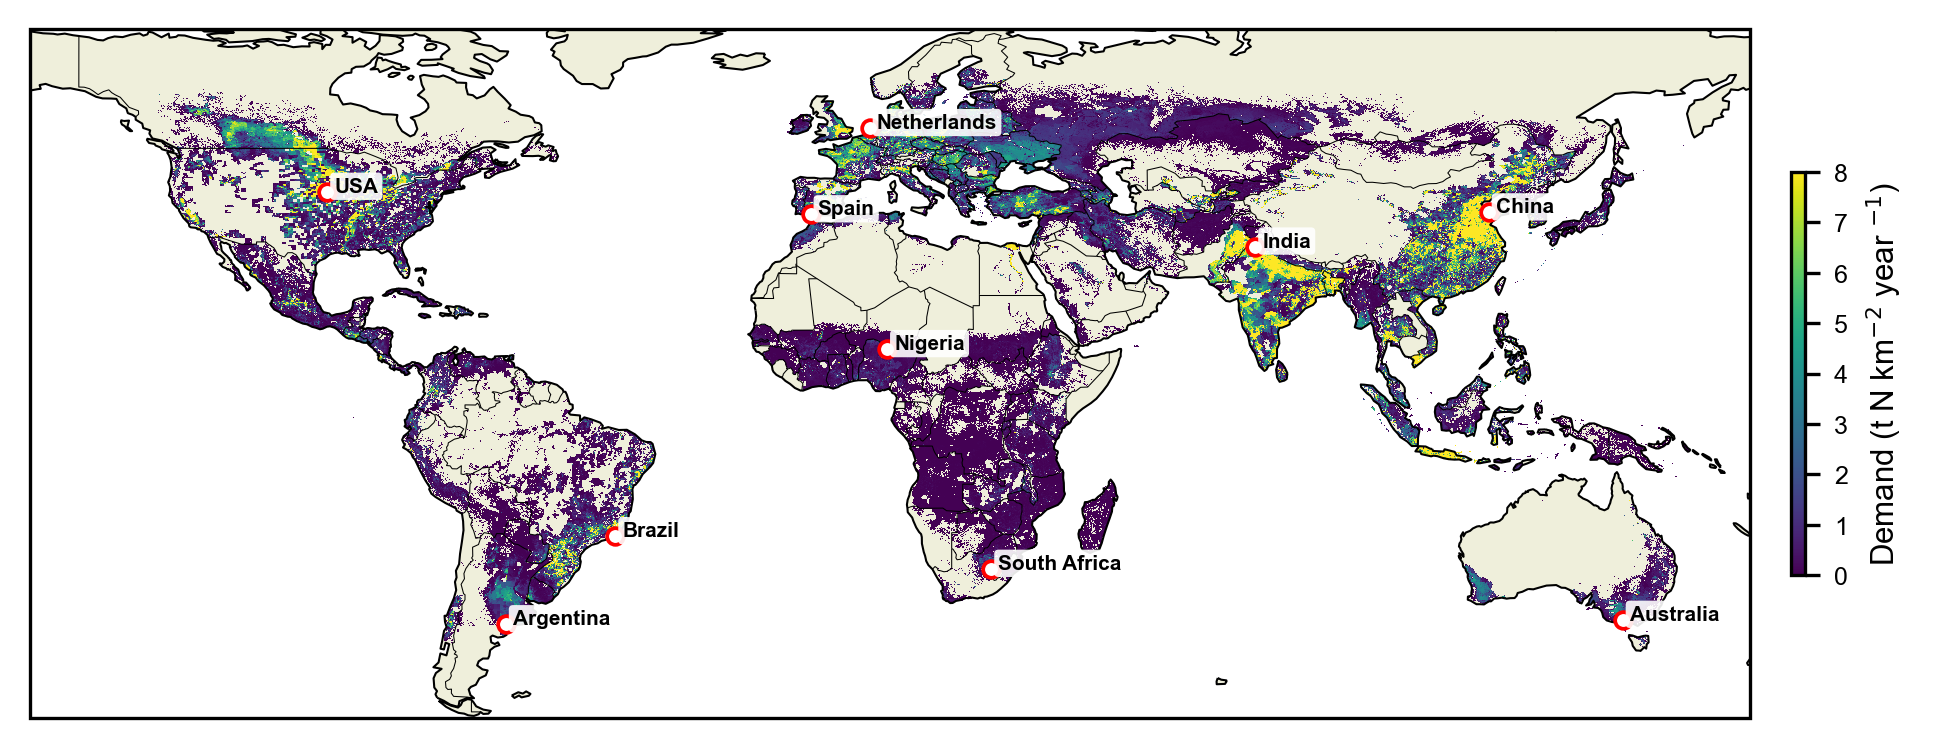

In [6]:
# Plotting Map of Nitrogen Demand per km2
synthetic_nitrogen_nonzero = np.ma.masked_equal(nitrogen_per_km2, 0)

width_mm = 180
height_mm = 90
dpi = 300
width_inch = width_mm / 25.4
height_inch = height_mm / 25.4

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6

fig = plt.figure(figsize=(width_inch, height_inch), dpi=dpi)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.25)
ax.set_extent([-150, 167, -56, 71], crs=ccrs.PlateCarree())

lons = np.linspace(-180, 180, synthetic_nitrogen_nonzero.shape[1])
lats = np.linspace(90, -90, synthetic_nitrogen_nonzero.shape[0])
#lon2d, lat2d = np.meshgrid(lons, lats)

heatmap = ax.pcolormesh(lons, lats, synthetic_nitrogen_nonzero,
                         cmap='viridis', vmax=8, transform=ccrs.PlateCarree())

# --- Add location points ---
for name, iso2, lat, lon in LOCATIONS:
    ax.scatter(lon, lat, s=16, c='white', edgecolor='red', linewidth=0.9,
               transform=ccrs.PlateCarree(), zorder=5)
    ax.text( lon + 1.3, lat, name.split("(", 1)[0].strip(), fontsize=5, fontweight='bold', 
            color='black', transform=ccrs.PlateCarree(), zorder=6,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, boxstyle='round,pad=0.2'))

cbar = fig.colorbar(
    heatmap, ax=ax, orientation='vertical',
    pad=0.02, aspect=30, shrink=0.4  #
)
cbar.set_label('Demand (t N km$^{-2}$ year $^{-1}$)', fontsize=7.5)
cbar.ax.tick_params(labelsize=6)  # adjust tick font

plt.tight_layout()
plt.savefig("figs/nitrogen_map_with_case_studies.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Store this data efficiently in an xarray, add also colum  for other data aspects

In [7]:
# --- 1. Define original fine grid ---
lat_res = 1/12
lon_res = 1/12
nlat, nlon = synthetic_nitrogen.shape

lats = np.linspace(90 - lat_res/2, -90 + lat_res/2, nlat)
lons = np.linspace(-180 + lon_res/2, 180 - lon_res/2, nlon)

# --- 2. Crop to smaller region BEFORE coarsening ---
min_lat, max_lat = -58, 70
min_lon, max_lon = -140, 170

lat_mask = (lats <= max_lat) & (lats >= min_lat)
lon_mask = (lons >= min_lon) & (lons <= max_lon)

synthetic_nitrogen_cropped = synthetic_nitrogen[np.ix_(lat_mask, lon_mask)]
lats_cropped = lats[lat_mask]
lons_cropped = lons[lon_mask]

# --- 3. Create DataArray ---
da_nitrogen = xr.DataArray(
    synthetic_nitrogen_cropped,
    coords=[("lat", lats_cropped), ("lon", lons_cropped)],
    name="synthetic_nitrogen_tonnes",
    attrs={
        "units": "tonnes",
        "description": "Synthetic nitrogen fertilizer demand in 2020",
        "resolution": f"{lat_res}° x {lon_res}°"
    }
)

# --- 4. Coarsen to 2° ---
da_nitrogen_2deg = da_nitrogen.coarsen(
    lat=int(DEG_RES / lat_res),
    lon=int(DEG_RES / lon_res),
    boundary="trim"
).sum()

# --- 5. Assign new coordinates for 2° cells ---
lat_2deg = np.arange(max_lat - DEG_RES / 2, min_lat, -DEG_RES)
lon_2deg = np.arange(min_lon + DEG_RES / 2, max_lon, DEG_RES)

da_nitrogen_2deg = da_nitrogen_2deg.assign_coords(lat=lat_2deg, lon=lon_2deg)

# --- 6. Initialize Dataset ---
ds = xr.Dataset(coords={"lat": da_nitrogen_2deg.lat, "lon": da_nitrogen_2deg.lon})
ds["synthetic_nitrogen_tonnes"] = da_nitrogen_2deg
ds["synthetic_nitrogen_tonnes"].attrs = da_nitrogen.attrs
ds

<xarray.Dataset> Size: 162kB
Dimensions:                    (lat: 128, lon: 310)
Coordinates:
  * lat                        (lat) float64 1kB 69.5 68.5 67.5 ... -56.5 -57.5
  * lon                        (lon) float64 2kB -139.5 -138.5 ... 168.5 169.5
Data variables:
    synthetic_nitrogen_tonnes  (lat, lon) float32 159kB 0.0 0.0 0.0 ... 0.0 0.0

# 3. Add additional info, like country, ISO2, land code etc.:

In [8]:
# --- 1. Create centroid points for each grid cell ---
lons, lats = np.meshgrid(ds.lon.values, ds.lat.values)
lons_flat = lons.ravel()
lats_flat = lats.ravel()
centroids = [Point(lon, lat) for lon, lat in zip(lons_flat, lats_flat)]

# --- 2. Create temporary GeoDataFrame of centroids ---
gdf_centroids = gpd.GeoDataFrame(
    {"lat": lats_flat, "lon": lons_flat},
    geometry=centroids,
    crs="EPSG:4326"
)

# --- 3. Assign country info via spatial join ---
countries = WORLD[['geometry', 'NAME_EN', 'ISO_A2', 'CONTINENT']].copy()
gdf_joined = gpd.sjoin(gdf_centroids, countries, how="left", predicate='within')

# Identify rows where ISO code is missing after the spatial join
unmatched = gdf_joined[gdf_joined['ISO_A2'] == '-99']
print(unmatched['NAME_EN'].unique())

[]


In [9]:
gdf_joined[gdf_joined['NAME_EN']=='Netherlands']

,lat,lon,geometry,index_right,NAME_EN,ISO_A2,CONTINENT
5414,52.5,4.5,POINT (4.5 52.5),130.0,Netherlands,NL,Europe
5415,52.5,5.5,POINT (5.5 52.5),130.0,Netherlands,NL,Europe
5416,52.5,6.5,POINT (6.5 52.5),130.0,Netherlands,NL,Europe
5724,51.5,4.5,POINT (4.5 51.5),130.0,Netherlands,NL,Europe
5725,51.5,5.5,POINT (5.5 51.5),130.0,Netherlands,NL,Europe


In [10]:
gdf_joined[gdf_joined['NAME_EN']=='Norway']

,lat,lon,geometry,index_right,NAME_EN,ISO_A2,CONTINENT
158,69.5,18.5,POINT (18.5 69.5),21.0,Norway,NO,Europe
159,69.5,19.5,POINT (19.5 69.5),21.0,Norway,NO,Europe
160,69.5,20.5,POINT (20.5 69.5),21.0,Norway,NO,Europe
161,69.5,21.5,POINT (21.5 69.5),21.0,Norway,NO,Europe
162,69.5,22.5,POINT (22.5 69.5),21.0,Norway,NO,Europe
163,69.5,23.5,POINT (23.5 69.5),21.0,Norway,NO,Europe
164,69.5,24.5,POINT (24.5 69.5),21.0,Norway,NO,Europe
165,69.5,25.5,POINT (25.5 69.5),21.0,Norway,NO,Europe
169,69.5,29.5,POINT (29.5 69.5),21.0,Norway,NO,Europe
170,69.5,30.5,POINT (30.5 69.5),21.0,Norway,NO,Europe


In [11]:
# --- 4. Sample raster values at centroids ---
# --- 5. Reshape results back to grid shape ---
shape = (len(ds.lat), len(ds.lon))
ds["NAME_EN"] = xr.DataArray(gdf_joined['NAME_EN'].values.reshape(shape),
                             coords={"lat": ds.lat, "lon": ds.lon}, dims=("lat", "lon"))
ds["ISO_A2"] = xr.DataArray(gdf_joined['ISO_A2'].values.reshape(shape),
                             coords={"lat": ds.lat, "lon": ds.lon}, dims=("lat", "lon"))
ds["CONTINENT"] = xr.DataArray(gdf_joined['CONTINENT'].values.reshape(shape),
                             coords={"lat": ds.lat, "lon": ds.lon}, dims=("lat", "lon"))
ds

<xarray.Dataset> Size: 1MB
Dimensions:                    (lat: 128, lon: 310)
Coordinates:
  * lat                        (lat) float64 1kB 69.5 68.5 67.5 ... -56.5 -57.5
  * lon                        (lon) float64 2kB -139.5 -138.5 ... 168.5 169.5
Data variables:
    synthetic_nitrogen_tonnes  (lat, lon) float32 159kB 0.0 0.0 0.0 ... 0.0 0.0
    NAME_EN                    (lat, lon) object 317kB 'Canada' nan ... nan nan
    ISO_A2                     (lat, lon) object 317kB 'CA' nan nan ... nan nan
    CONTINENT                  (lat, lon) object 317kB 'North America' ... nan

In [12]:
ds.where(ds.NAME_EN == 'Switzerland', drop=True)

<xarray.Dataset> Size: 272B
Dimensions:                    (lat: 2, lon: 4)
Coordinates:
  * lat                        (lat) float64 16B 47.5 46.5
  * lon                        (lon) float64 32B 6.5 7.5 8.5 9.5
Data variables:
    synthetic_nitrogen_tonnes  (lat, lon) float32 32B nan ... 1.871e+03
    NAME_EN                    (lat, lon) object 64B nan ... 'Switzerland'
    ISO_A2                     (lat, lon) object 64B nan 'CH' 'CH' ... 'CH' 'CH'
    CONTINENT                  (lat, lon) object 64B nan 'Europe' ... 'Europe'

In [13]:
ds.where(ds.NAME_EN == 'France', drop=True)

<xarray.Dataset> Size: 6kB
Dimensions:                    (lat: 13, lon: 15)
Coordinates:
  * lat                        (lat) float64 104B 50.5 49.5 48.5 ... 4.5 3.5 2.5
  * lon                        (lon) float64 120B -53.5 -52.5 -4.5 ... 6.5 7.5
Data variables:
    synthetic_nitrogen_tonnes  (lat, lon) float32 780B nan nan nan ... nan nan
    NAME_EN                    (lat, lon) object 2kB nan nan nan ... nan nan nan
    ISO_A2                     (lat, lon) object 2kB nan nan nan ... nan nan nan
    CONTINENT                  (lat, lon) object 2kB nan nan nan ... nan nan nan

# Finally prepare xarray by adding solar and wind hourly capacity factor:

In [14]:
# Example: create your time dimension
TIME = pd.date_range("2025-01-01", periods=8760, freq="h")  # one year hourly

# Assuming your dataset already has lat/lon
lat = ds.lat.values
lon = ds.lon.values

# Add the time coordinate if not already present
ds = ds.assign_coords(time=TIME)

# --- initialize dynamic hourly variables ---
dynamic_cols = ["cf_solar", "cf_wind"]

for col in dynamic_cols:
    ds[col] = xr.DataArray(
        np.full((len(TIME), len(lat), len(lon)), np.nan, dtype=float),
        coords={"time": TIME, "lat": lat, "lon": lon},
        dims=("time", "lat", "lon"),
    )
ds

<xarray.Dataset> Size: 6GB
Dimensions:                    (lat: 128, lon: 310, time: 8760)
Coordinates:
  * lat                        (lat) float64 1kB 69.5 68.5 67.5 ... -56.5 -57.5
  * lon                        (lon) float64 2kB -139.5 -138.5 ... 168.5 169.5
  * time                       (time) datetime64[ns] 70kB 2025-01-01 ... 2025...
Data variables:
    synthetic_nitrogen_tonnes  (lat, lon) float32 159kB 0.0 0.0 0.0 ... 0.0 0.0
    NAME_EN                    (lat, lon) object 317kB 'Canada' nan ... nan nan
    ISO_A2                     (lat, lon) object 317kB 'CA' nan nan ... nan nan
    CONTINENT                  (lat, lon) object 317kB 'North America' ... nan
    cf_solar                   (time, lat, lon) float64 3GB nan nan ... nan nan
    cf_wind                    (time, lat, lon) float64 3GB nan nan ... nan nan

In [15]:
from config import N_DEMAND_THRESHOLD

In [16]:
masked_ds = ds.where(ds.synthetic_nitrogen_tonnes > N_DEMAND_THRESHOLD, drop=True)
masked_ds.synthetic_nitrogen_tonnes.sum()

<xarray.DataArray 'synthetic_nitrogen_tonnes' ()> Size: 4B
array(98885288., dtype=float32)

In [17]:
masked_ds.synthetic_nitrogen_tonnes.sum()/ds.synthetic_nitrogen_tonnes.sum()

<xarray.DataArray 'synthetic_nitrogen_tonnes' ()> Size: 4B
array(1.0000001, dtype=float32)

# Important, EXPORT FILE:

In [18]:
# Save (serialize) the xarray dataset
with open(OUTPUT_FILE_XARRAY_INIT, "wb") as f:
    pickle.dump(ds, f)

print(f"Dataset saved to {OUTPUT_FILE_XARRAY_INIT}")

Dataset saved to processed_data/output_dataset_res_1.pkl


### Plot for some checks

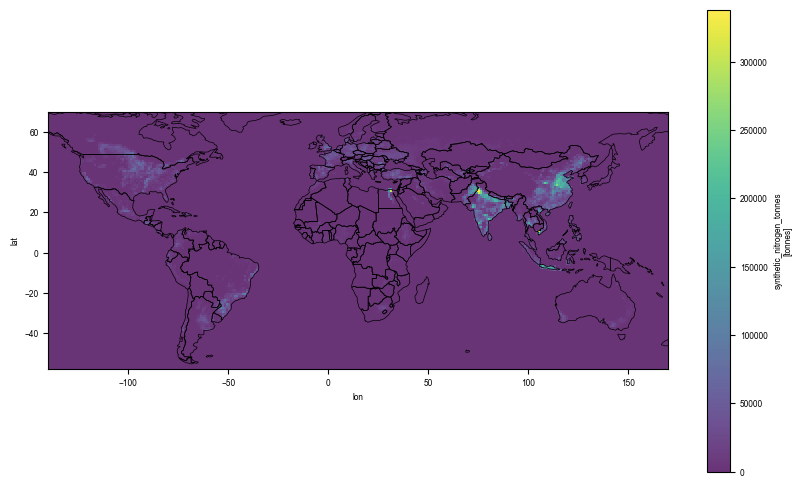

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
ds["synthetic_nitrogen_tonnes"].plot(ax=ax, cmap="viridis", alpha=0.8)
WORLD.boundary.plot(ax=ax, color="black", linewidth=0.5)
plt.show()